Word2Vec is a word embedding technique that converts words into dense vectors of numbers while preserving their meaning and relationships.

One-Line Definition

Word2Vec is a neural network-based model that learns vector representations of words from text data.

Why Do We Need It?

Bag of Words (BoW) and TF-IDF represent words as counts but do not understand meaning.

GloVe (Global Vectors for Word Representation)

GloVe is a word embedding technique that converts words into dense vectors by using word co-occurrence statistics from the entire corpus.

One-Line Definition

GloVe is a word embedding model that learns word vectors using global word co-occurrence information.

Idea Behind GloVe

If two words frequently appear together, their vectors should be similar.

Example:

ice → cold, frozen, winter
steam → hot, water, heat

In [ ]:
import numpy as np
def cosine_similarity(a,b):
  return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
good=np.array([0.82,0.41,0.10])
great=np.array([0.79,0.38,0.12])
bad=np.array([-0.71,0.12,-0.05])
print(f'good vs great :{cosine_similarity(good,great):3f}')
print(f'good vs bad :{cosine_similarity(good,bad):3f}')
print(f'great vs bad :{cosine_similarity(great,bad):3f}')

good vs great :0.999509
good vs bad :-0.808214
great vs bad :-0.816236


In [ ]:

!pip install gensim
from gensim.models import Word2Vec
# A small corpus — in practice use millions of sentences
sentences = [
'the king ruled the kingdom wisely',
'the queen ruled the land gracefully',
'the prince will become king one day',
'a man walked into the palace',
'a woman walked into the palace',
'the dog barked loudly in the garden',
'the puppy played happily in the garden',
]
# Tokenise each sentence into a list of words
tokenised = [s.split() for s in sentences]
# Train Word2Vec
# vector_size=50: each word gets a 50-number vector
# window=3: look 3 words left and right for context
# sg=1: use Skip-gram (sg=0 for CBOW)
# epochs=200: pass through the data 200 times
model = Word2Vec(sentences=tokenised, vector_size=50,
window=3, min_count=1, sg=1, epochs=200)
# Find top-3 most similar words to 'king'
print(model.wv.most_similar('king', topn=3))
# [('queen', 0.91), ('prince', 0.88), ('kingdom', 0.85)]
# The famous analogy: king - man + woman
result = model.wv.most_similar(
positive=['king', 'woman'], # add these
negative=['man'], # subtract this
topn=1
)
print('king - man + woman =', result[0][0]) # 'queen'


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.7 MB/s eta 0:00:00
[('kingdom', 0.40141454339027405), ('played', 0.38476690649986267), ('in', 0.38395753502845764)]
king - man + woman = ruled


import gensim.downloader as api
ft=api.load('fasttext-wiki-news-subwords-300')
print(ft.most_similar('bollywood', topn=5))
print(ft.similarity('dog', 'puppy'))
print(ft.similarity('cat', 'cricket'))

In [ ]:
import gensim.downloader as api
ft=api.load('fasttext-wiki-news-subwords-300')
print(ft.most_similar('bollywood', topn=5))

In [ ]:
import gensim.downloader as api
glove=api.load('glove-wiki-gigaword-50')
print(glove.most_similar('tollywood', topn=5))

[('malayalam', 0.8092038035392761), ('kannada', 0.7827341556549072), ('telugu', 0.7818781733512878), ('oriya', 0.754660964012146), ('lollywood', 0.741540789604187)]


Missing words: {'shravanthparis', 'rama chandra'}
Vector matrix shape: (15, 50)


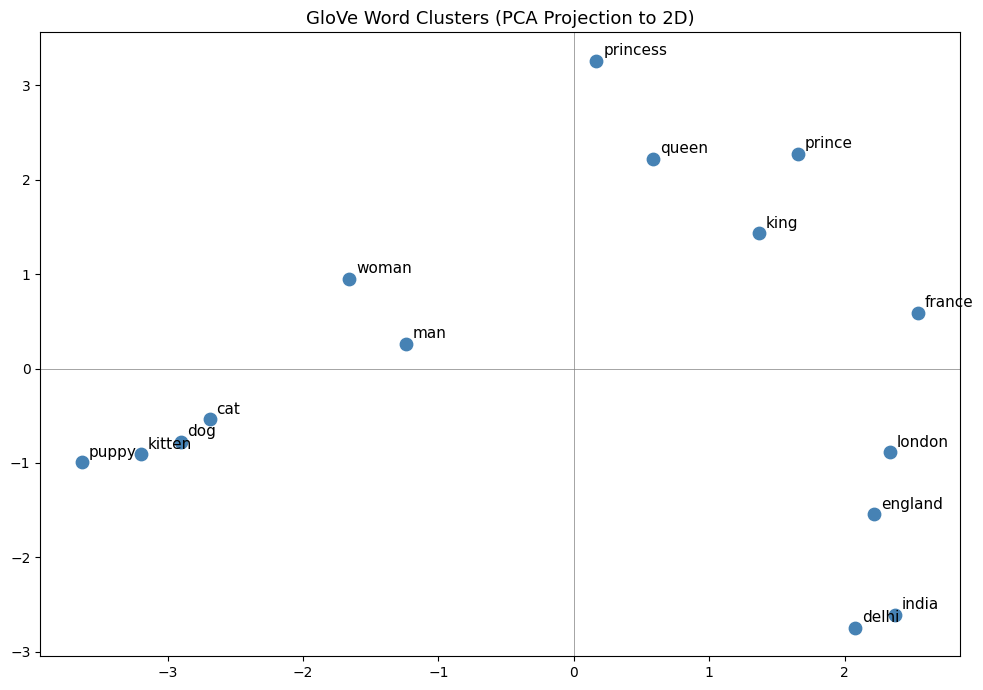

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import KeyedVectors

# Assuming you already loaded GloVe:
# glove = KeyedVectors.load_word2vec_format(
#     'glove.6B.100d.w2v.txt',
#     binary=False
# )

# Words to visualize
words = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess',
    'dog', 'puppy', 'cat', 'kitten','rama chandra','shravanth'
    'paris', 'france', 'delhi', 'india', 'london', 'england'
]

# Keep only words that exist in the model
valid_words = [w for w in words if w in glove.key_to_index]

missing_words = set(words) - set(valid_words)
if missing_words:
    print("Missing words:", missing_words)

# Extract vectors
vectors = np.array([glove[w] for w in valid_words])

print("Vector matrix shape:", vectors.shape)

# Reduce dimensions from 100D -> 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=80,
    color='steelblue',
    zorder=3
)

# Add labels
for i, word in enumerate(valid_words):
    ax.annotate(
        word,
        (coords[i, 0], coords[i, 1]),
        fontsize=11,
        xytext=(5, 4),
        textcoords='offset points'
    )

ax.set_title(
    'GloVe Word Clusters (PCA Projection to 2D)',
    fontsize=13
)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('word_clusters.png', dpi=150)
plt.show()